# Import Libraries

In [16]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [18]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [20]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [9]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [11]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [13]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis France's Group Stage games

In [22]:
team = "France Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
22,3893798,France Women's,Jamaica Women's,Group
23,3893798,Jamaica Women's,France Women's,Group
56,3893815,Brazil Women's,France Women's,Group
57,3893815,France Women's,Brazil Women's,Group
84,3893829,France Women's,Panama Women's,Group
85,3893829,Panama Women's,France Women's,Group


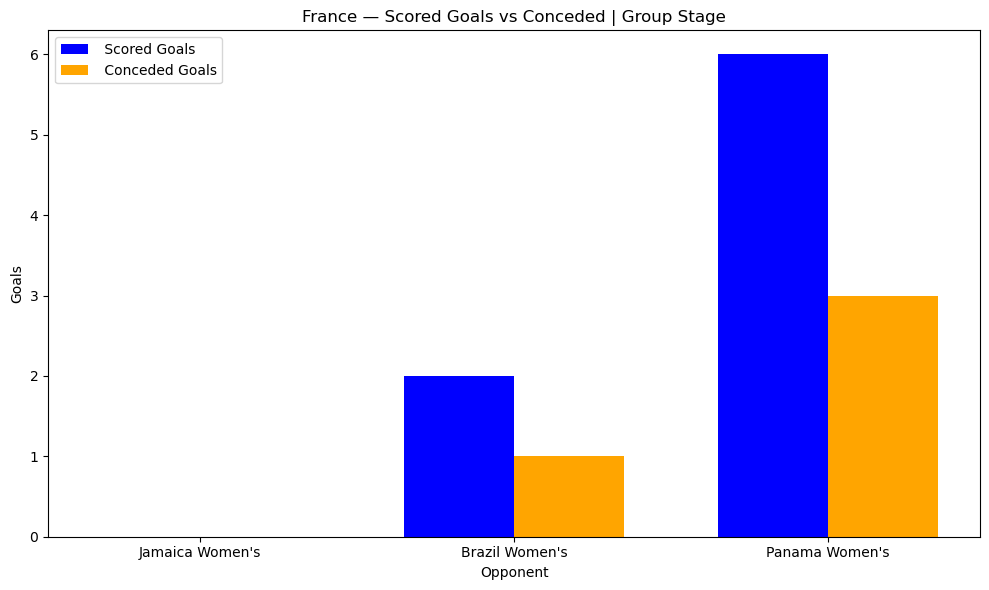

In [24]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "France Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("France — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

France won two games despite conceding goals to their opponents and tied one game without scoring any goals.

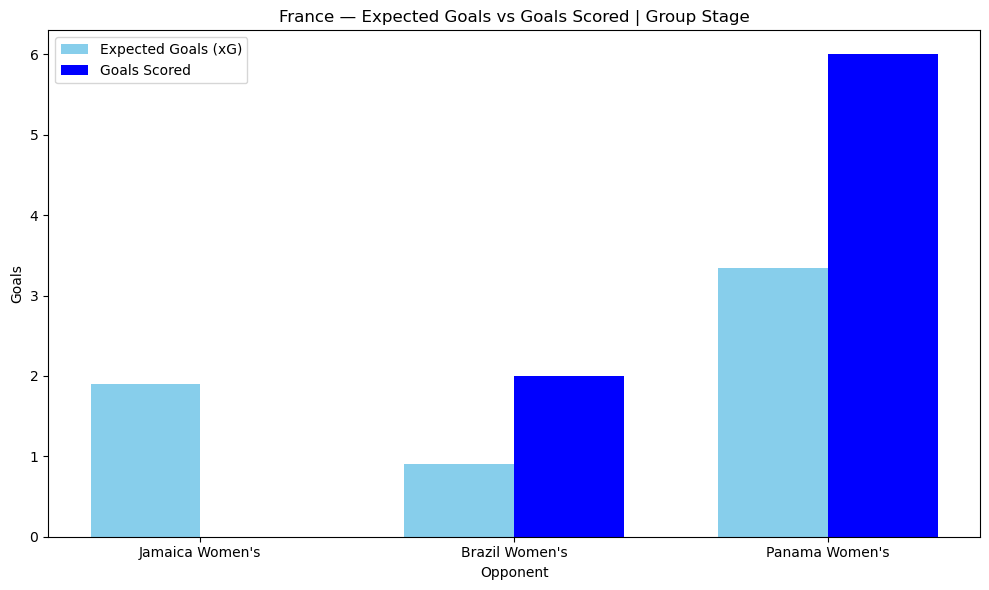

In [26]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "France Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("France — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

The French national team generated more xG than it actually scored, which may indicate a lack of efficiency or finishing ability.

# Analysis FRA-JAM

In [33]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "France": [
        match.loc[
            match["team"] == "France Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Jamaica": [
        match.loc[
            match["team"] == "Jamaica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Jamaica"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Jamaica"]
].round(1)


# Display table

comparison

,Metric,France,Jamaica
0,Goals,0.0,0.0
1,xG,1.9,0.2
2,Goals Minus xG,-1.9,-0.2
3,Shots,14.0,6.0
4,Shots on Target,5.0,2.0
5,Saves,2.0,5.0
6,Possession %,69.8,30.2
7,Pass Accuracy %,76.7,50.9
8,Progressive Passes,121.0,70.0
9,Progressive Carries,16.0,11.0


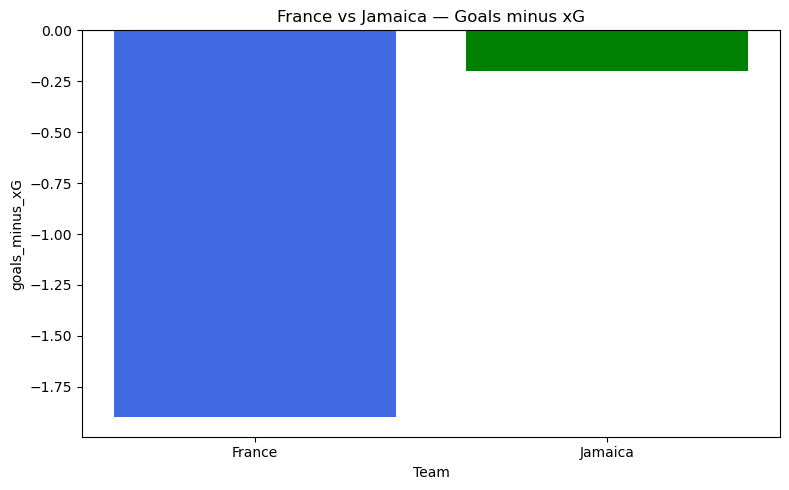

In [42]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


teams = ["France", "Jamaica"]

goals_minus_xG = [
    match.loc[match["team"] == "France Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Jamaica Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["royalblue", "green"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("France vs Jamaica — Goals minus xG")

plt.tight_layout()
plt.show()

Both teams underperformed, with France experiencing a steeper decline (xG 1.9 and no goals scored).

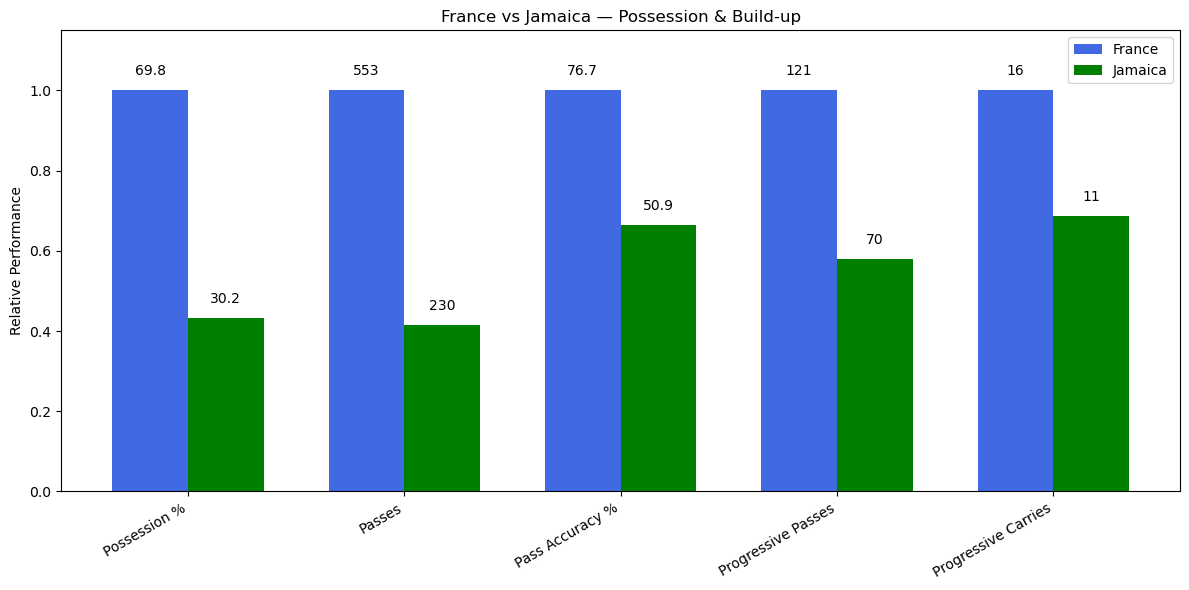

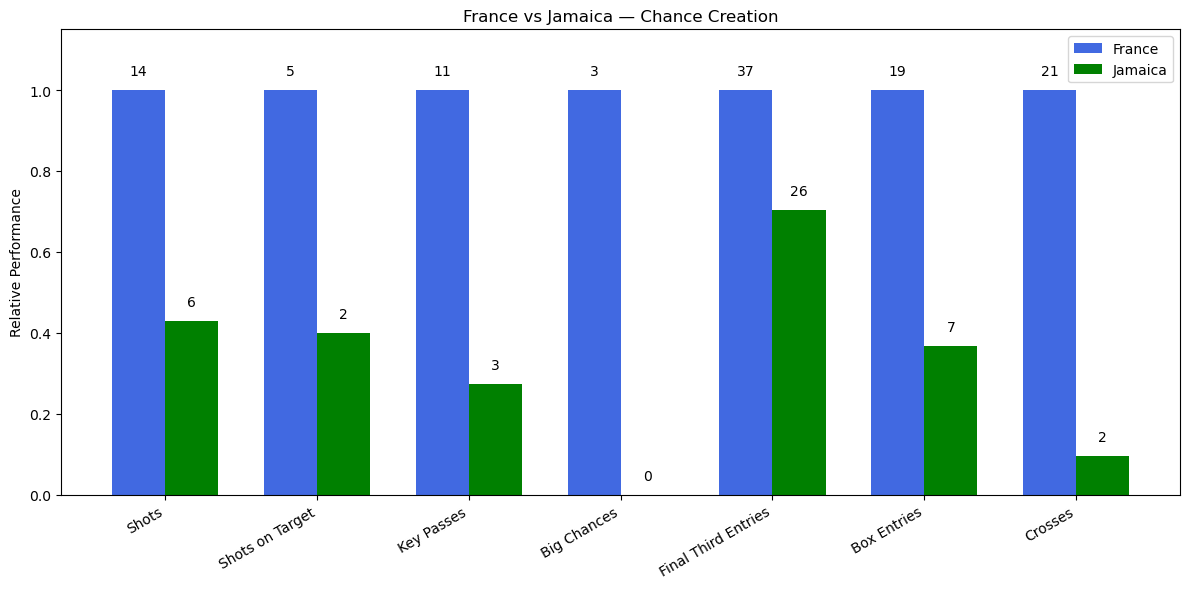

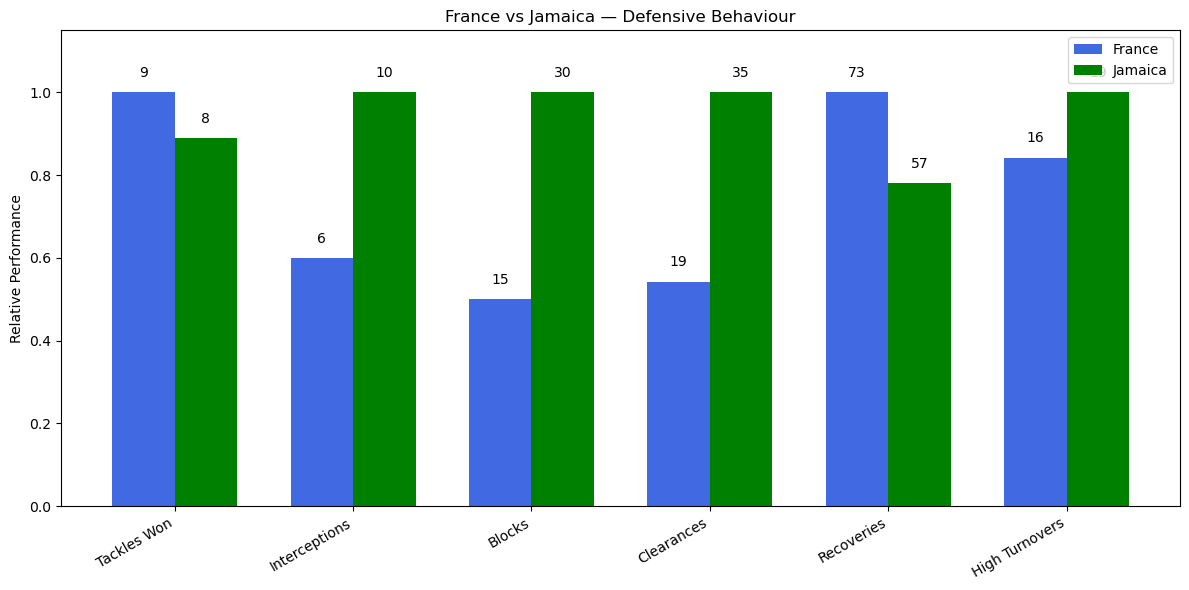

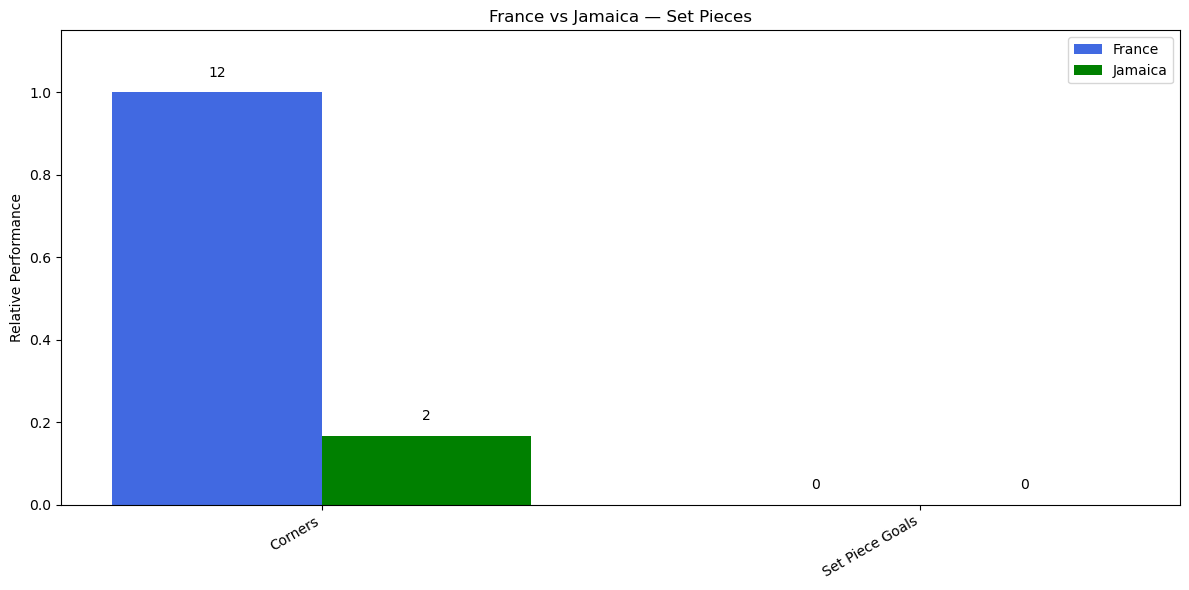

In [44]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "France": "France Women's",
    "Jamaica": "Jamaica Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    fra_values = np.array([
        match.loc[
            match["team"] == team_names["France"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    jam_values = np.array([
        match.loc[
            match["team"] == team_names["Jamaica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(fra_values, jam_values)

    # Normalize
    fra_normalized = np.divide(
        fra_values,
        max_values,
        out=np.zeros_like(fra_values),
        where=max_values != 0
    )

    jam_normalized = np.divide(
        jam_values,
        max_values,
        out=np.zeros_like(jam_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_fra = plt.bar(
        x - width / 2,
        fra_normalized,
        width,
        label="France",
        color="royalblue"
    )

    bars_jam = plt.bar(
        x + width / 2,
        jam_normalized,
        width,
        label="Jamaica",
        color="green"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_fra, fra_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_jam, jam_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"France vs Jamaica — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion FRA-JAM

France dominated the match against Jamaica. However, some statistics stand out in a positive light for the Caribbean nation, as shown in the *defensive performance* chart (specifically the following metrics:<br>
- Interceptions: 10-6
- Blocks: 30-15
- Clearances: 35-19 
<br>

This may well explain their ability to counter France’s offensive approach. Despite leading in most of the metrics evaluated, France was somewhat scattered on offense, resulting in high numbers but few goals.

# Analysis FRA-BRA

In [53]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "France": [
        match.loc[
            match["team"] == "France Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Brazil": [
        match.loc[
            match["team"] == "Brazil Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Brazil"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Brazil"]
].round(1)


# Display table

comparison

,Metric,France,Brazil
0,Goals,2.0,1.0
1,xG,0.9,1.0
2,Goals Minus xG,1.1,0.0
3,Shots,20.0,11.0
4,Shots on Target,7.0,2.0
5,Saves,1.0,5.0
6,Possession %,52.9,47.1
7,Pass Accuracy %,69.1,68.9
8,Progressive Passes,105.0,98.0
9,Progressive Carries,15.0,9.0


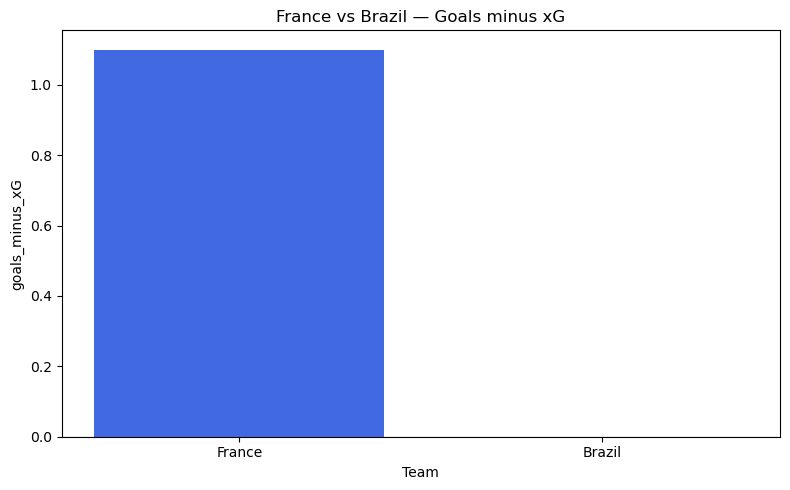

In [55]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


teams = ["France", "Brazil"]

goals_minus_xG = [
    match.loc[match["team"] == "France Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Brazil Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["royalblue", "yellow"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("France vs Brazil — Goals minus xG")

plt.tight_layout()
plt.show()

In the chart shown, Brazil met the xG projection—that is, 1 goal. France, on the other hand, exceeded its xG, thereby increasing the number of goals scored (2).

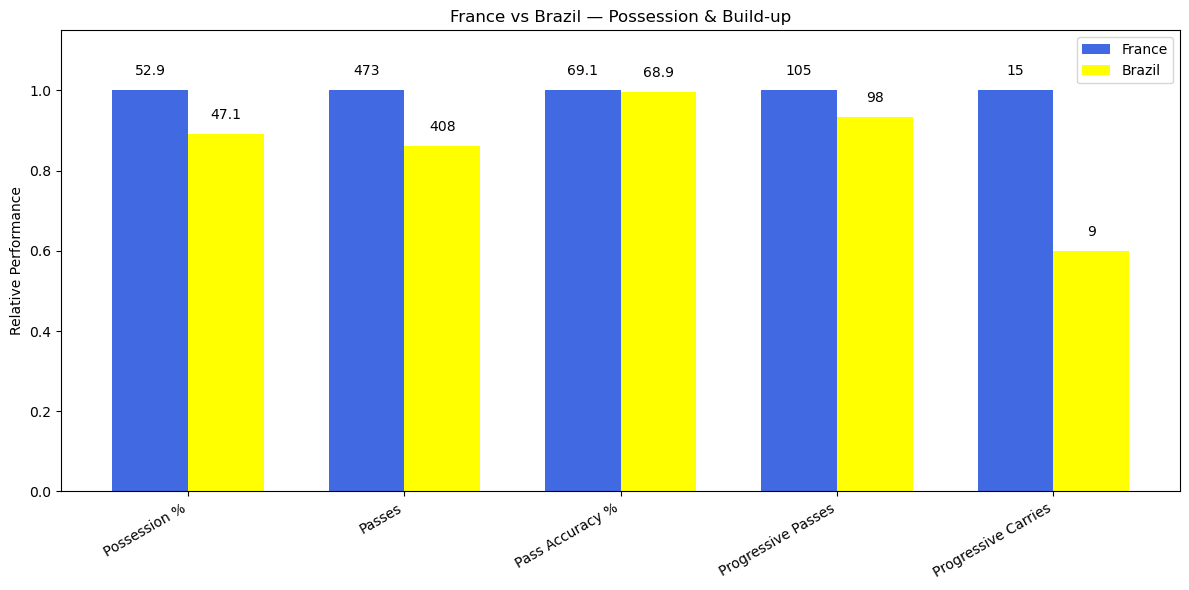

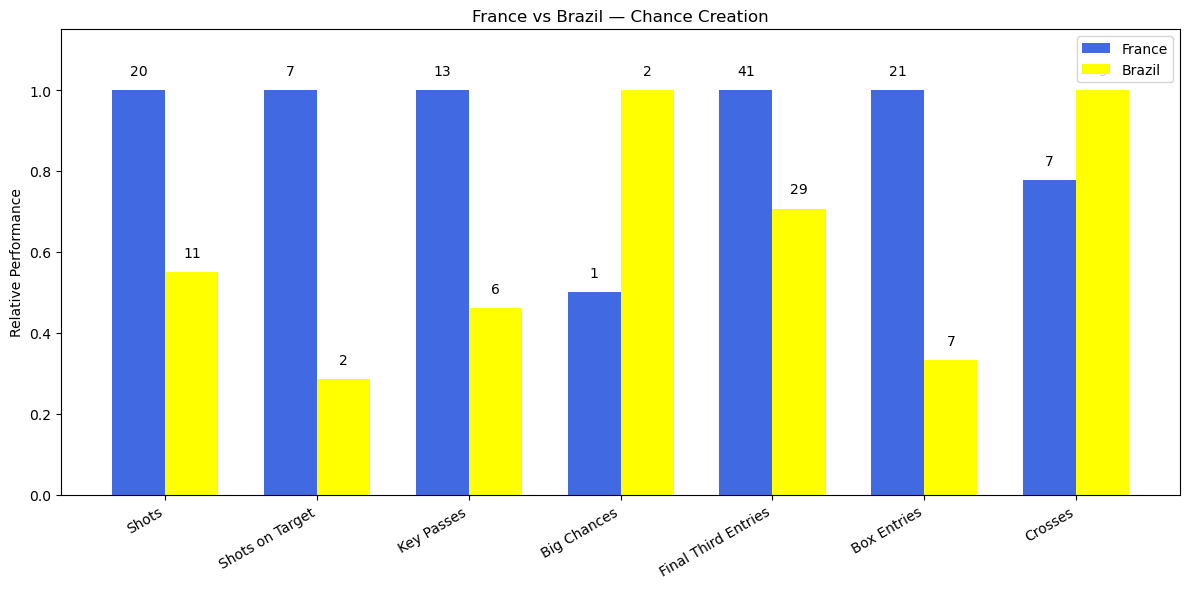

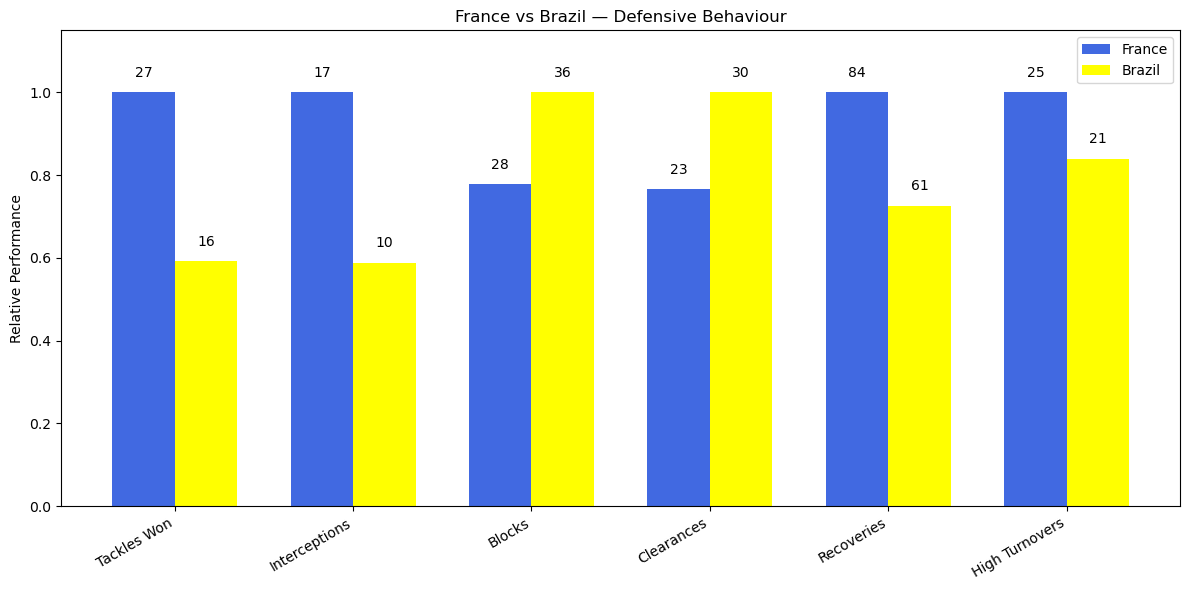

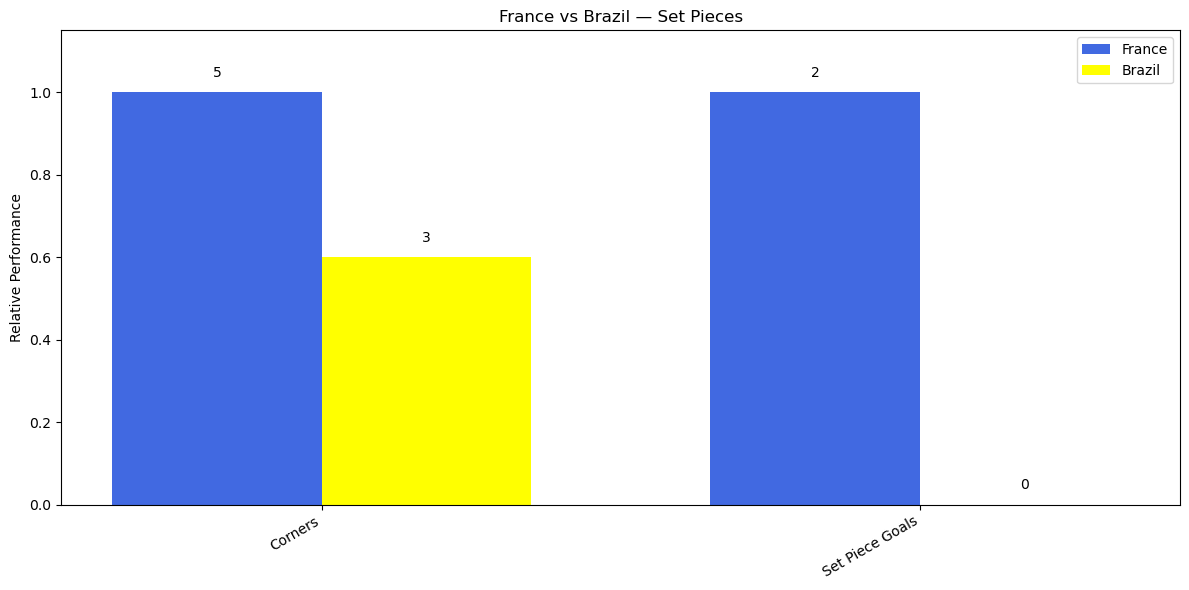

In [60]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "France": "France Women's",
    "Brazil": "Brazil Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    fra_values = np.array([
        match.loc[
            match["team"] == team_names["France"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    br_values = np.array([
        match.loc[
            match["team"] == team_names["Brazil"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(fra_values, br_values)

    # Normalize
    fra_normalized = np.divide(
        fra_values,
        max_values,
        out=np.zeros_like(fra_values),
        where=max_values != 0
    )

    br_normalized = np.divide(
        br_values,
        max_values,
        out=np.zeros_like(br_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_fra = plt.bar(
        x - width / 2,
        fra_normalized,
        width,
        label="France",
        color="royalblue"
    )

    bars_br = plt.bar(
        x + width / 2,
        br_normalized,
        width,
        label="Brazil",
        color="yellow"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_fra, fra_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_br, br_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"France vs Brazil — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion FRA-BRA

The match between France and Brazil was closely contested, with both teams evenly matched.<br>
As the charts show, France led in most metrics, but Brazil remained highly competitive. 

# Analysis FRA-PAN

In [70]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "France": [
        match.loc[
            match["team"] == "France Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Panama": [
        match.loc[
            match["team"] == "Panama Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Panama"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["France", "Panama"]
].round(1)


# Display table

comparison

,Metric,France,Panama
0,Goals,6.0,3.0
1,xG,3.3,1.4
2,Goals Minus xG,2.7,1.6
3,Shots,26.0,6.0
4,Shots on Target,8.0,3.0
5,Saves,0.0,2.0
6,Possession %,63.3,36.7
7,Pass Accuracy %,80.3,53.5
8,Progressive Passes,148.0,63.0
9,Progressive Carries,39.0,8.0


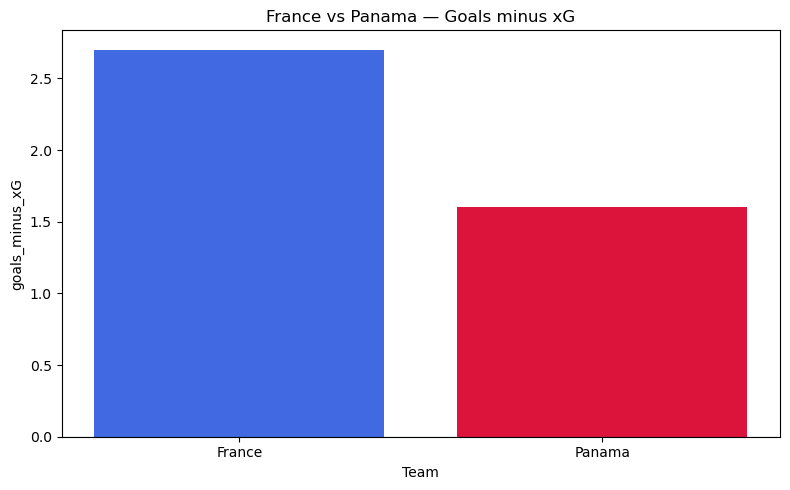

In [72]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


teams = ["France", "Panama"]

goals_minus_xG = [
    match.loc[match["team"] == "France Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Panama Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["royalblue", "crimson"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("France vs Panama — Goals minus xG")

plt.tight_layout()
plt.show()

Both teams exceeded their projected xG and performed better than expected.

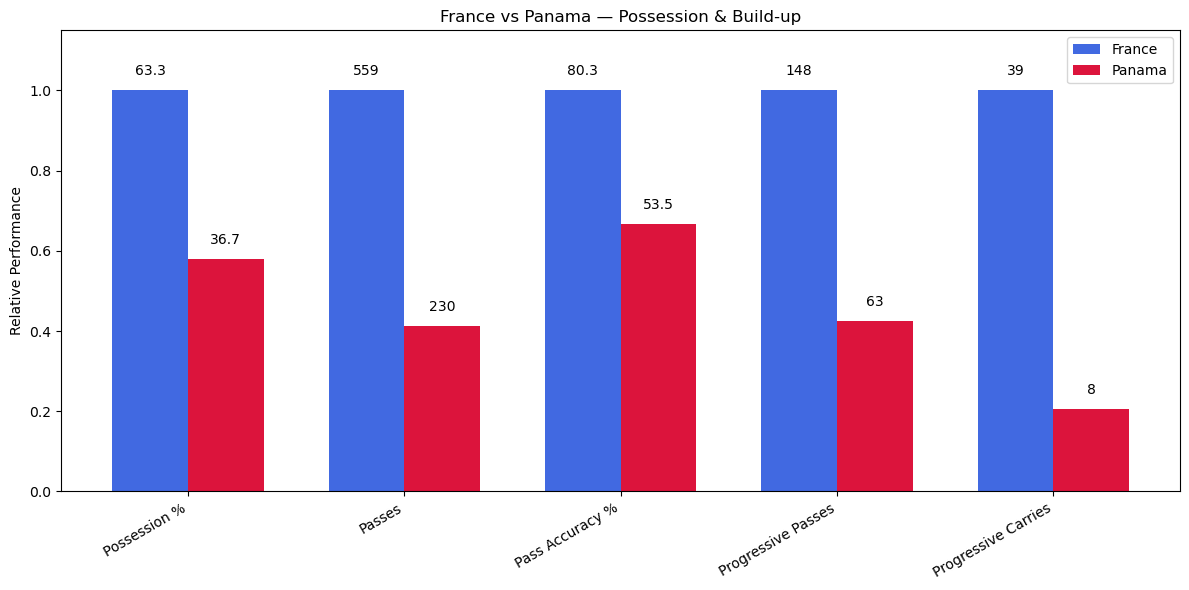

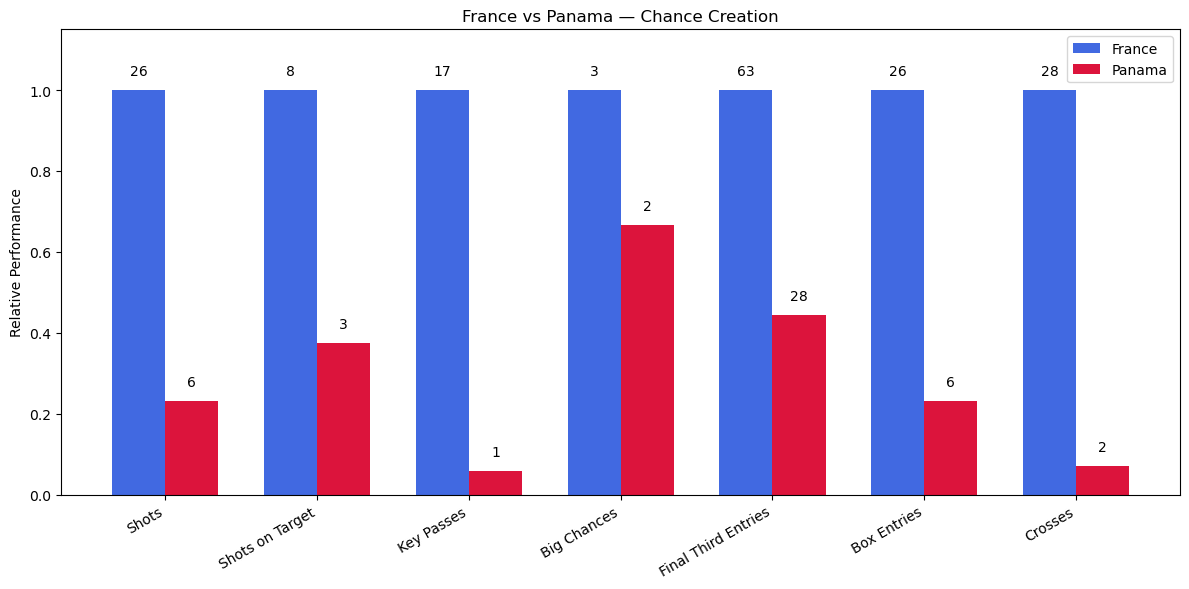

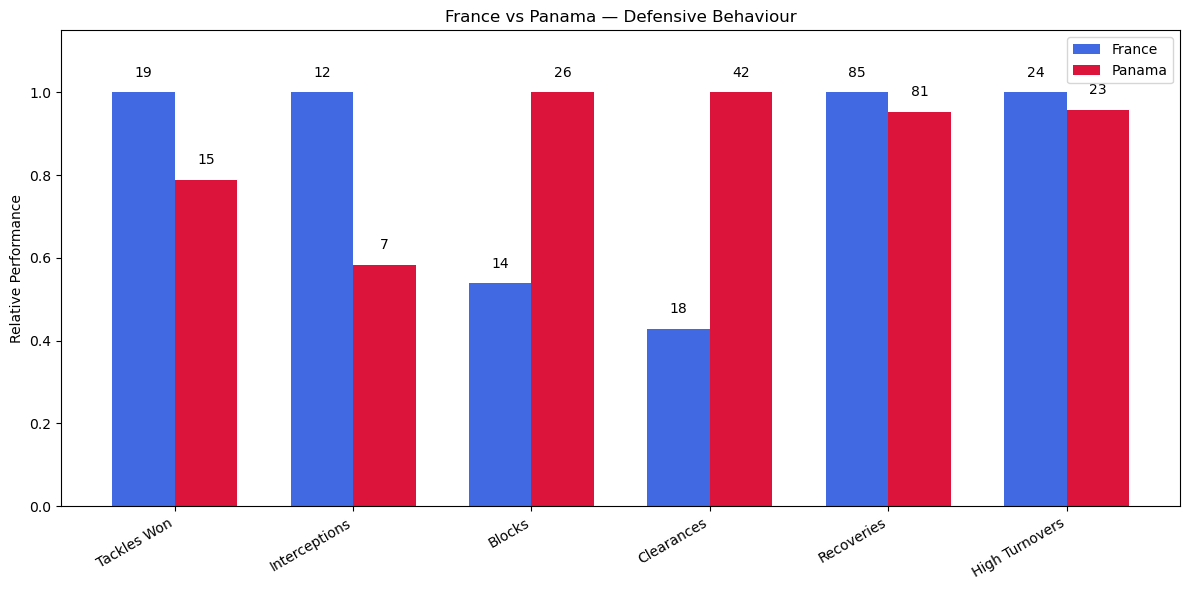

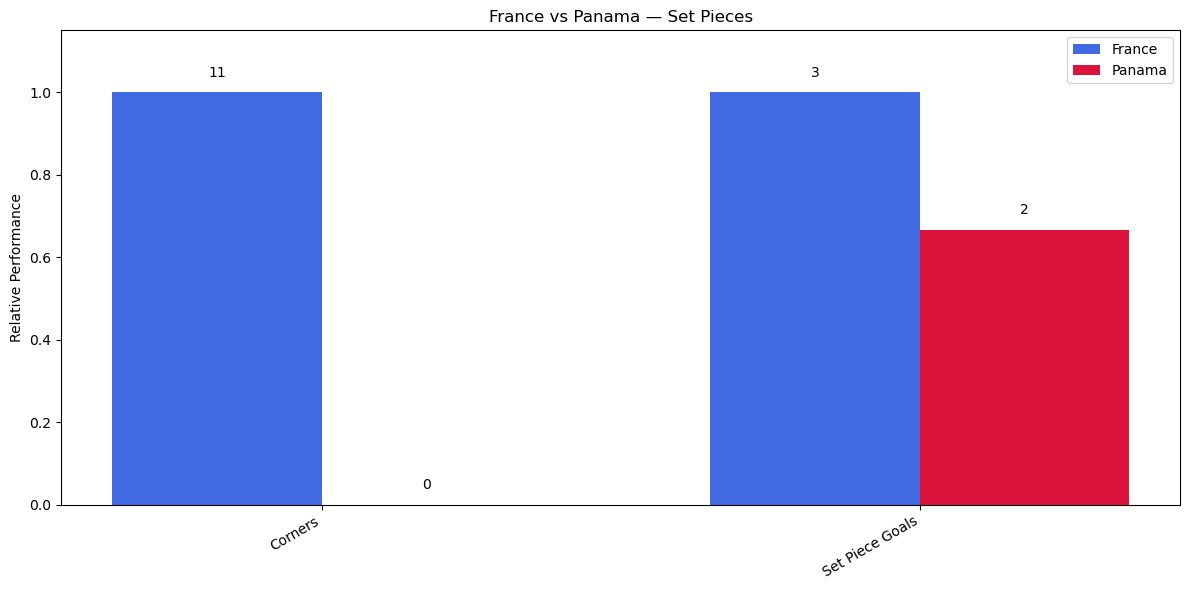

In [75]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "France Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "France Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "France": "France Women's",
    "Panama": "Panama Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    fra_values = np.array([
        match.loc[
            match["team"] == team_names["France"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    pan_values = np.array([
        match.loc[
            match["team"] == team_names["Panama"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(fra_values, pan_values)

    # Normalize
    fra_normalized = np.divide(
        fra_values,
        max_values,
        out=np.zeros_like(fra_values),
        where=max_values != 0
    )

    pan_normalized = np.divide(
        pan_values,
        max_values,
        out=np.zeros_like(pan_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_fra = plt.bar(
        x - width / 2,
        fra_normalized,
        width,
        label="France",
        color="royalblue"
    )

    bars_pan = plt.bar(
        x + width / 2,
        pan_normalized,
        width,
        label="Panama",
        color="crimson"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_fra, fra_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_pan, pan_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"France vs Panama — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion FRA-PAN

France dominated the game against Panama; however, there were some shortcomings in their finishing statistics:
- Of 26 shots, only 8 were on target, and 6 were brilliantly converted into goals. 
This means that 18 shots went wide. <br>
<br>

Panama, on the other hand, was quite productive. Despite having significantly lower statistics than their opponent, they managed to:
- out of 6 shots, 3 were on target, and all 3 were converted into goals.

# Analysis Jamaica's Group Stage games

In [86]:
team = "Jamaica Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
22,3893798,France Women's,Jamaica Women's,Group
23,3893798,Jamaica Women's,France Women's,Group
58,3893816,Jamaica Women's,Panama Women's,Group
59,3893816,Panama Women's,Jamaica Women's,Group
90,3893832,Brazil Women's,Jamaica Women's,Group
91,3893832,Jamaica Women's,Brazil Women's,Group


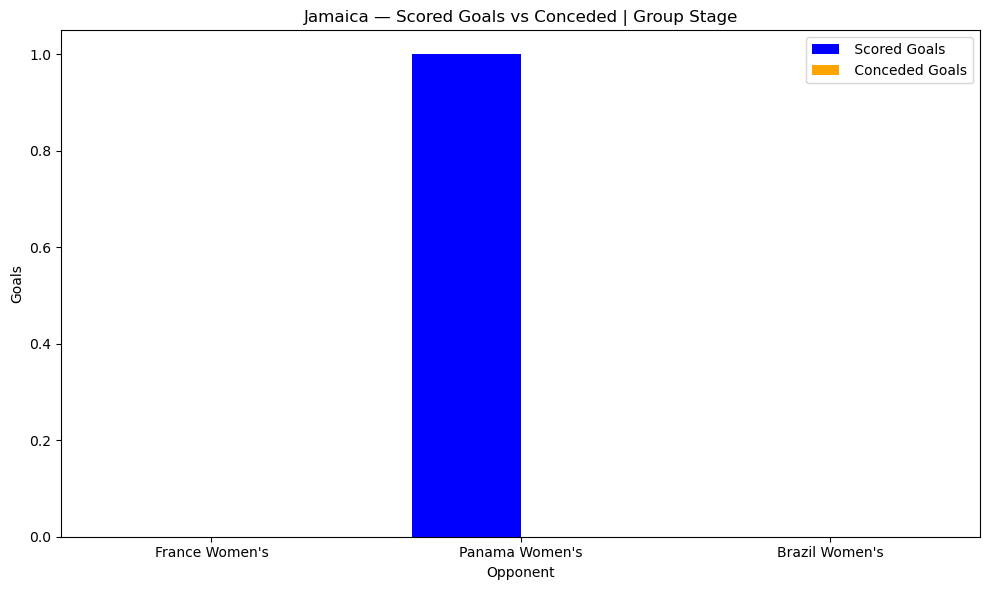

In [88]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Jamaica Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Jamaica — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Jamaica won one game and tied two games.

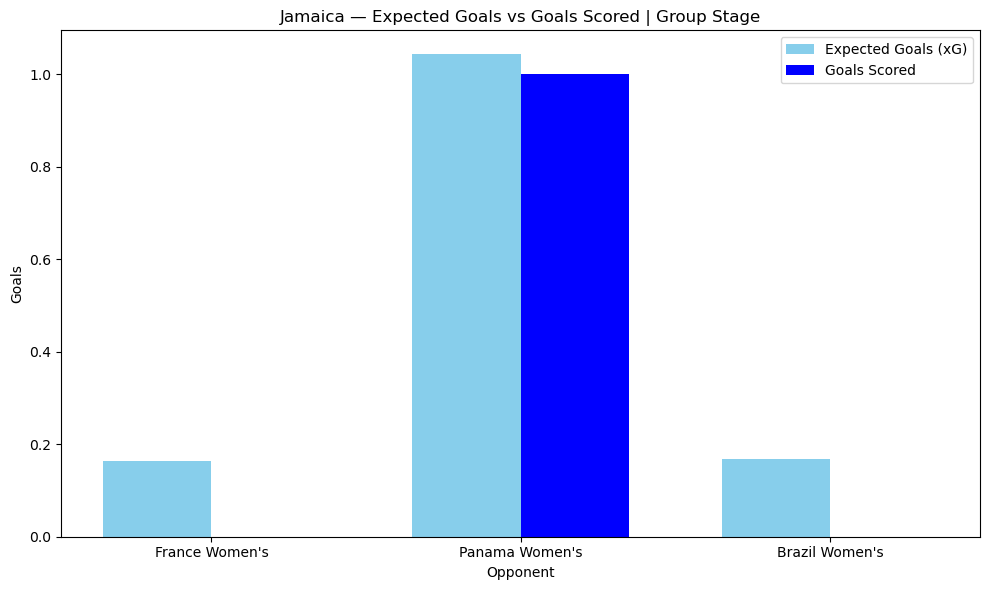

In [91]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Jamaica Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Jamaica — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Jamaica underperformed in the three games they played.

# Analysis JAM-BRA

In [98]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Jamaica": [
        match.loc[
            match["team"] == "Jamaica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Brazil": [
        match.loc[
            match["team"] == "Brazil Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Jamaica", "Brazil"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Jamaica", "Brazil"]
].round(1)


# Display table

comparison

,Metric,Jamaica,Brazil
0,Goals,0.0,0.0
1,xG,0.2,1.3
2,Goals Minus xG,-0.2,-1.3
3,Shots,3.0,18.0
4,Shots on Target,0.0,8.0
5,Saves,8.0,0.0
6,Possession %,29.5,70.5
7,Pass Accuracy %,51.1,76.6
8,Progressive Passes,86.0,142.0
9,Progressive Carries,16.0,32.0


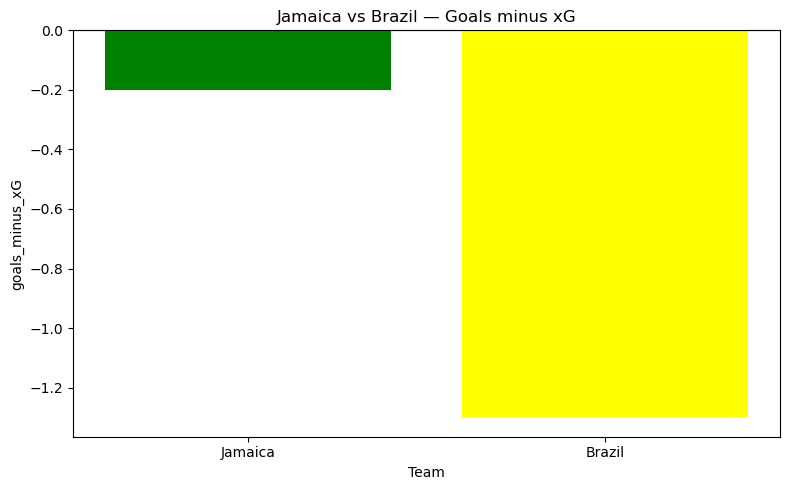

In [100]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()

teams = ["Jamaica", "Brazil"]

goals_minus_xG = [
    match.loc[match["team"] == "Jamaica Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Brazil Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["green", "yellow"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Jamaica vs Brazil — Goals minus xG")

plt.tight_layout()
plt.show()

Both teams fell short of their expected xG. Brazil had the largest discrepancy, failing to score any goals when nearly 2 were expected.

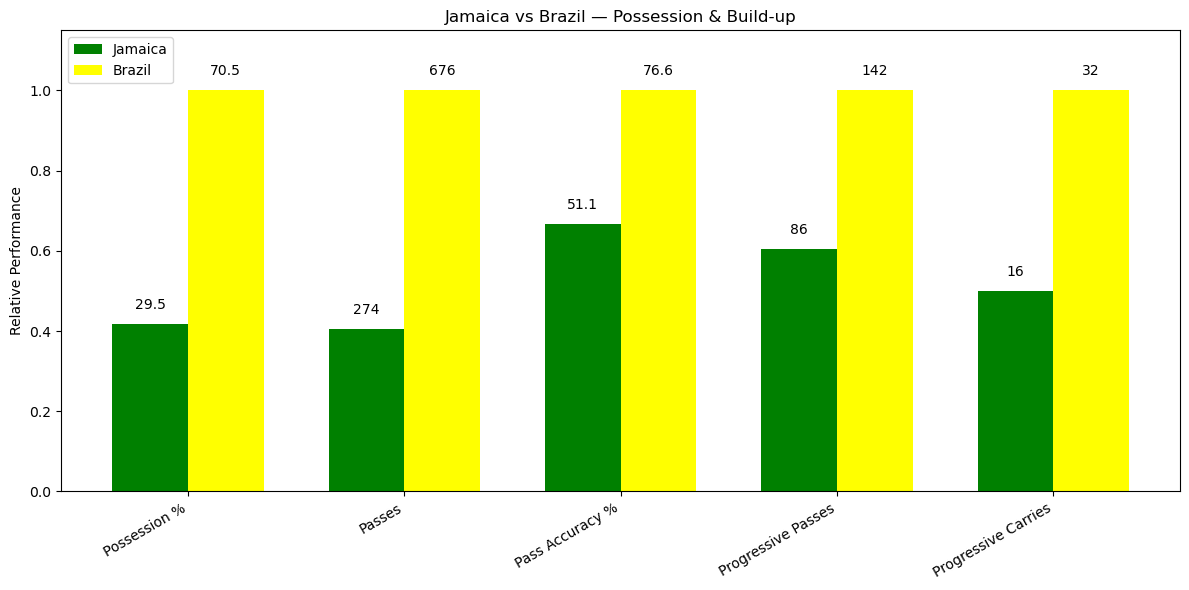

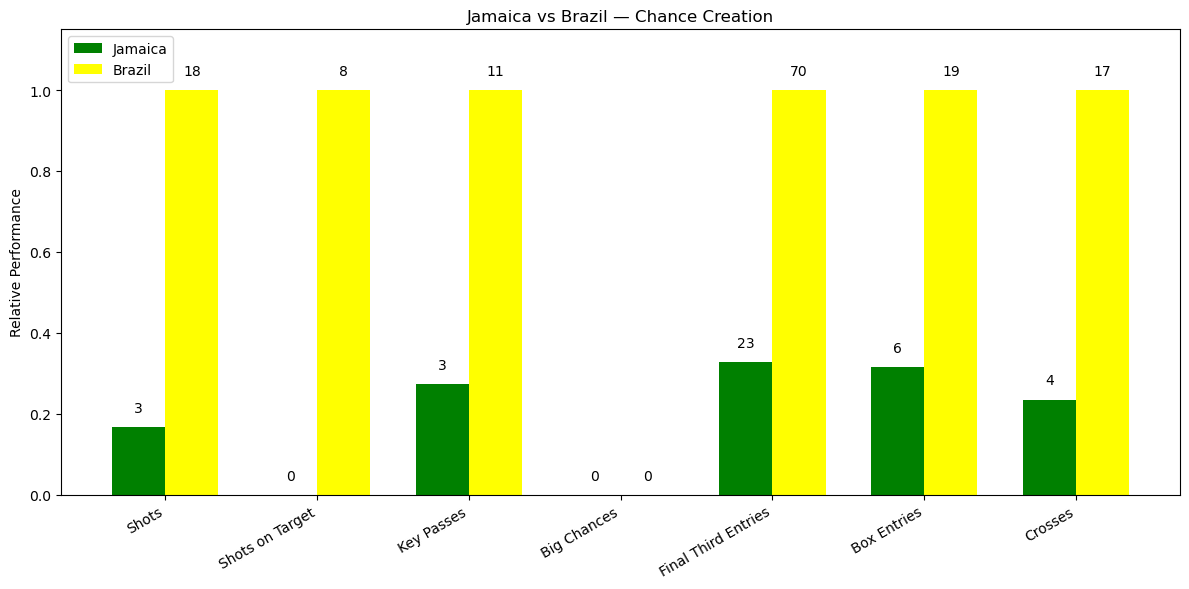

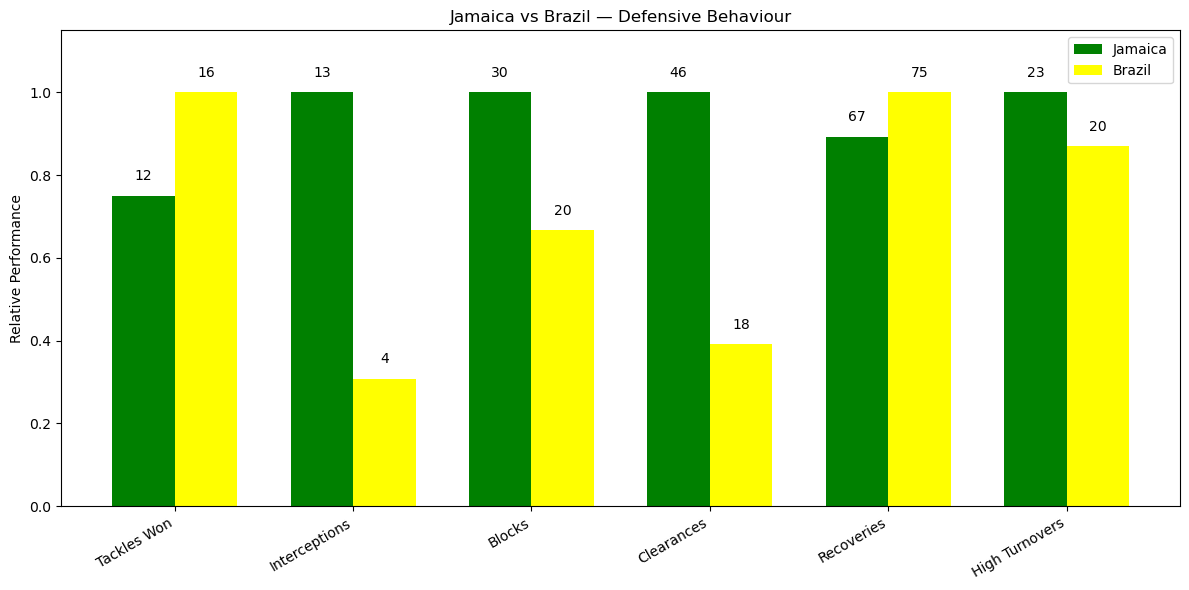

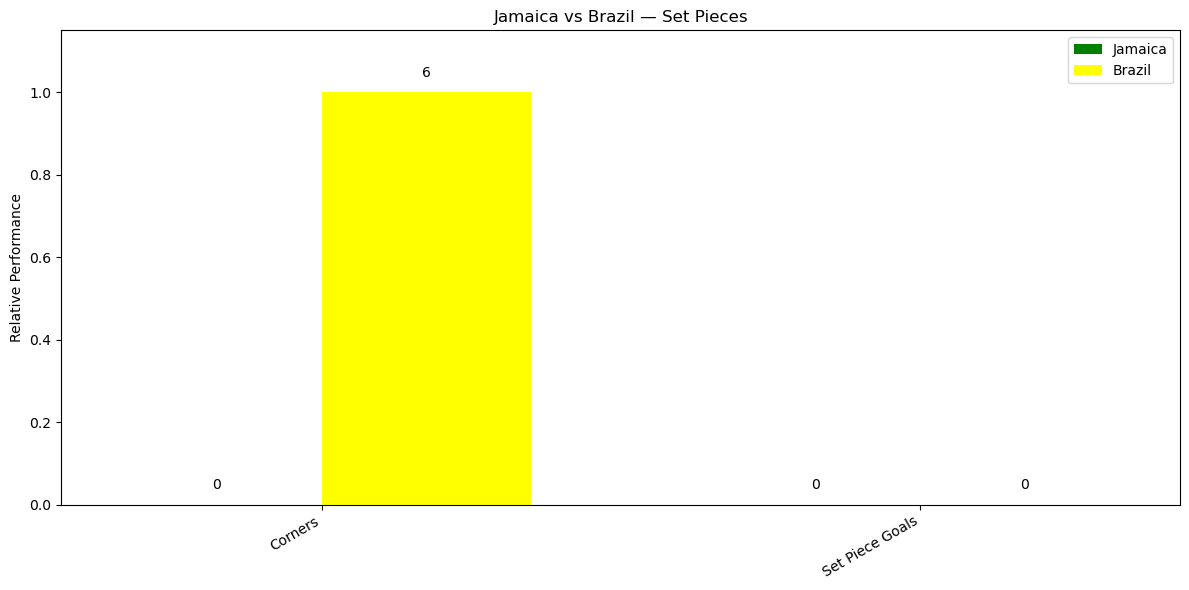

In [103]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Jamaica": "Jamaica Women's",
    "Brazil": "Brazil Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    jam_values = np.array([
        match.loc[
            match["team"] == team_names["Jamaica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    br_values = np.array([
        match.loc[
            match["team"] == team_names["Brazil"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(jam_values, br_values)

    # Normalize
    jam_normalized = np.divide(
        jam_values,
        max_values,
        out=np.zeros_like(jam_values),
        where=max_values != 0
    )

    br_normalized = np.divide(
        br_values,
        max_values,
        out=np.zeros_like(br_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_jam = plt.bar(
        x - width / 2,
        jam_normalized,
        width,
        label="Jamaica",
        color="green"
    )

    bars_br = plt.bar(
        x + width / 2,
        br_normalized,
        width,
        label="Brazil",
        color="yellow"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_jam, jam_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_br, br_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Jamaica vs Brazil — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion JAM-BRA

In the match shown, Brazil appeared to be the team that controlled the entire game. The possession and attack statistics reveal figures that differ significantly when compared.<br>
However, Jamaica’s defense outperformed Brazil’s, managing to stop all of the South American team’s shots on goal.

# Analysis JAM-PAN

In [109]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Jamaica": [
        match.loc[
            match["team"] == "Jamaica Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Panama": [
        match.loc[
            match["team"] == "Panama Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Jamaica", "Panama"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Jamaica", "Panama"]
].round(1)


# Display table

comparison

,Metric,Jamaica,Panama
0,Goals,1.0,0.0
1,xG,1.0,0.5
2,Goals Minus xG,-0.0,-0.5
3,Shots,21.0,13.0
4,Shots on Target,4.0,4.0
5,Saves,4.0,4.0
6,Possession %,51.9,48.1
7,Pass Accuracy %,71.4,70.2
8,Progressive Passes,91.0,95.0
9,Progressive Carries,21.0,18.0


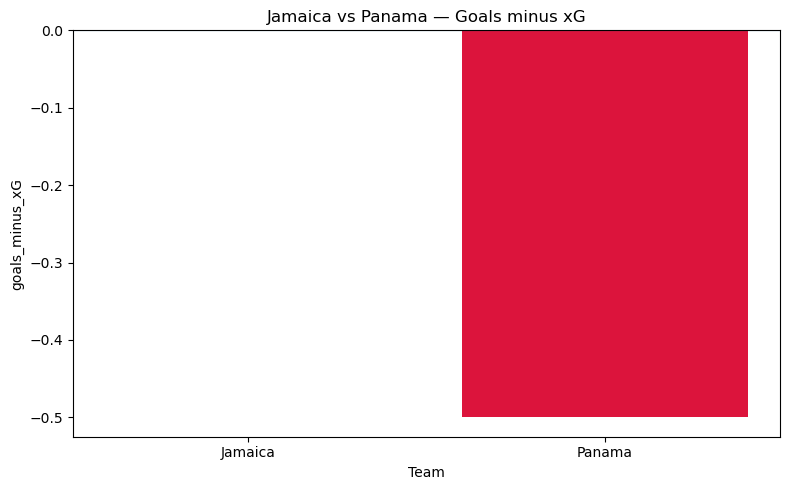

In [111]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()


teams = ["Jamaica", "Panama"]

goals_minus_xG = [
    match.loc[match["team"] == "Jamaica Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Panama Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["green", "crimson"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Jamaica vs Panama — Goals minus xG")

plt.tight_layout()
plt.show()

Jamaica managed to stay on par with its xG, scoring one goal, while Panama fell short of its xG.

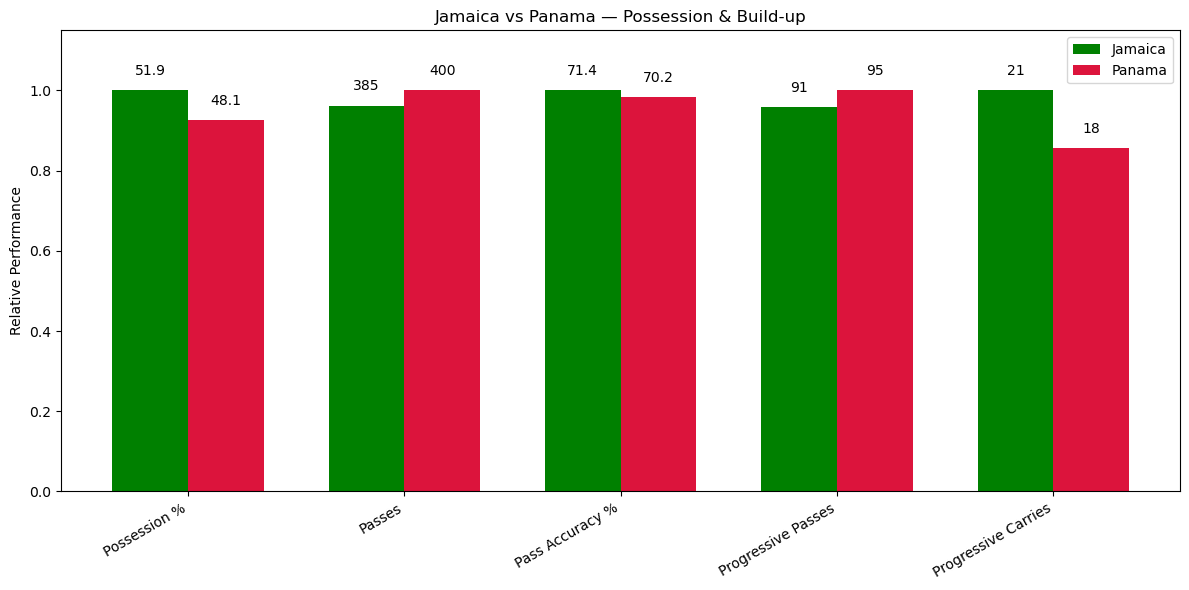

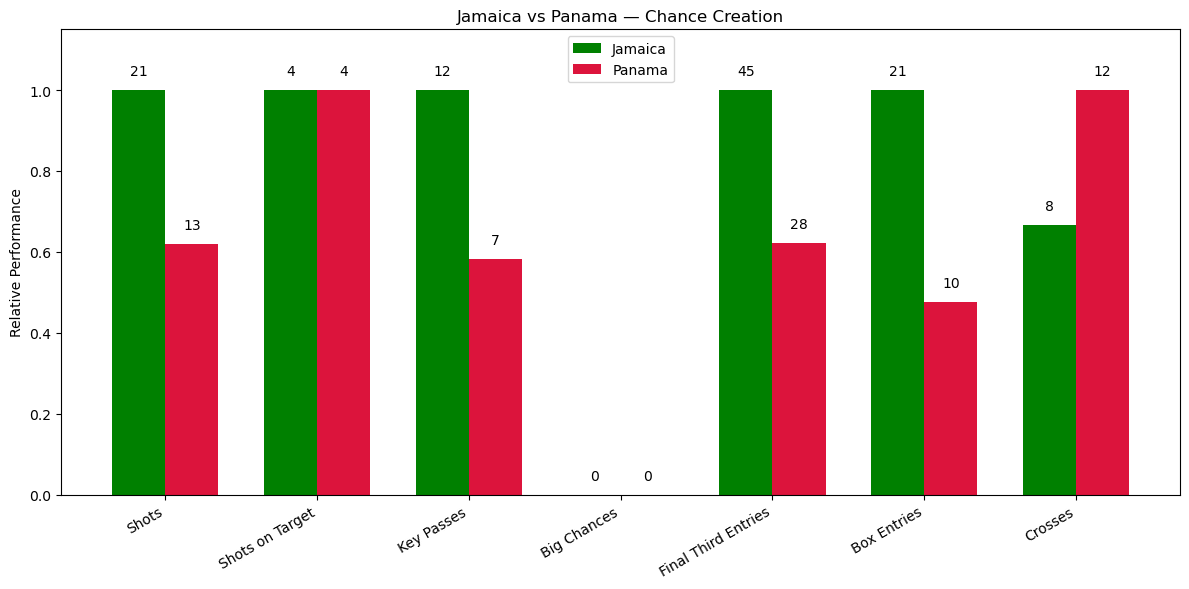

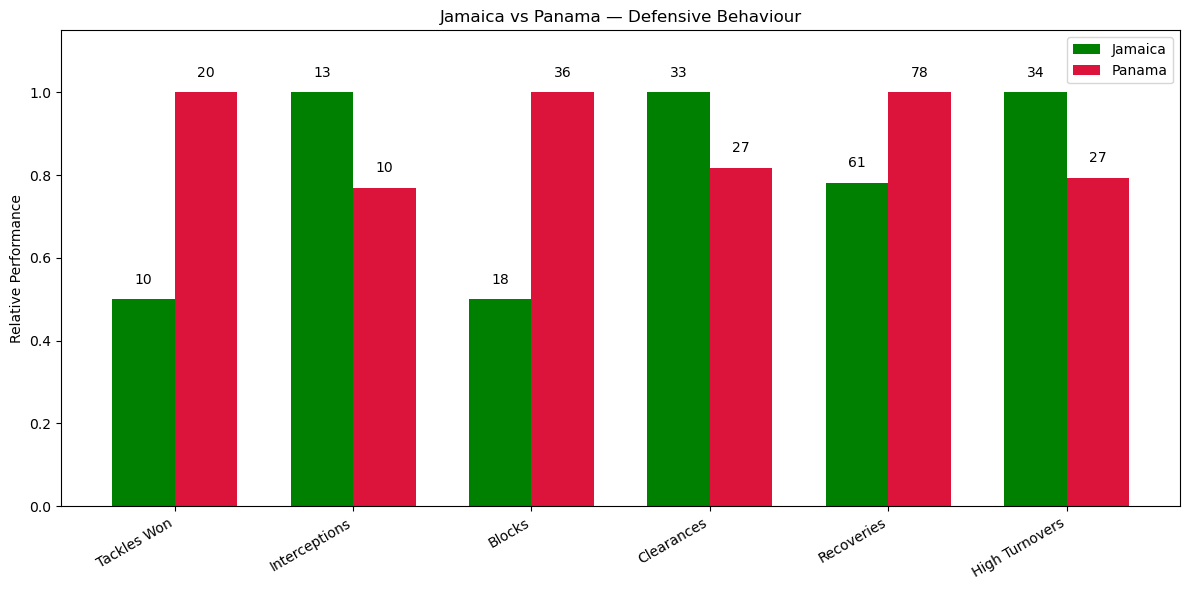

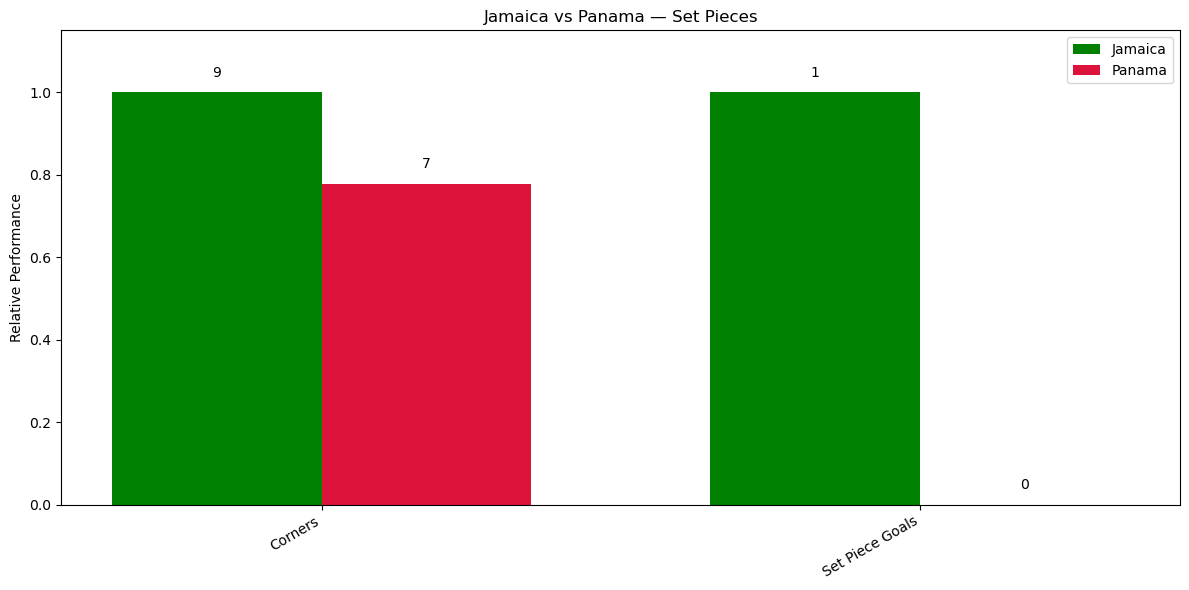

In [118]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Jamaica Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "Jamaica Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Jamaica": "Jamaica Women's",
    "Panama": "Panama Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    jam_values = np.array([
        match.loc[
            match["team"] == team_names["Jamaica"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    pan_values = np.array([
        match.loc[
            match["team"] == team_names["Panama"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(jam_values, pan_values)

    # Normalize
    jam_normalized = np.divide(
        jam_values,
        max_values,
        out=np.zeros_like(jam_values),
        where=max_values != 0
    )

    pan_normalized = np.divide(
        pan_values,
        max_values,
        out=np.zeros_like(pan_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_jam = plt.bar(
        x - width / 2,
        jam_normalized,
        width,
        label="Jamaica",
        color="green"
    )

    bars_pan = plt.bar(
        x + width / 2,
        pan_normalized,
        width,
        label="Panama",
        color="crimson"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_jam, jam_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_pan, pan_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Jamaica vs Panama — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion JAM-PAN 

Jamaica showed slight dominance in the game, with more possession, shots, xG, and a greater presence in the final third and in the box. Although both teams had four shots on target, Jamaica was more effective and ultimately won 1-0. Panama stood out primarily on defense, with more successful tackles, blocks, and ball recoveries, but struggled to turn that solid defense into scoring opportunities.

# Analysis Brazil's Group Stage games

In [123]:
team = "Brazil Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
28,3893801,Brazil Women's,Panama Women's,Group
29,3893801,Panama Women's,Brazil Women's,Group
56,3893815,Brazil Women's,France Women's,Group
57,3893815,France Women's,Brazil Women's,Group
90,3893832,Brazil Women's,Jamaica Women's,Group
91,3893832,Jamaica Women's,Brazil Women's,Group


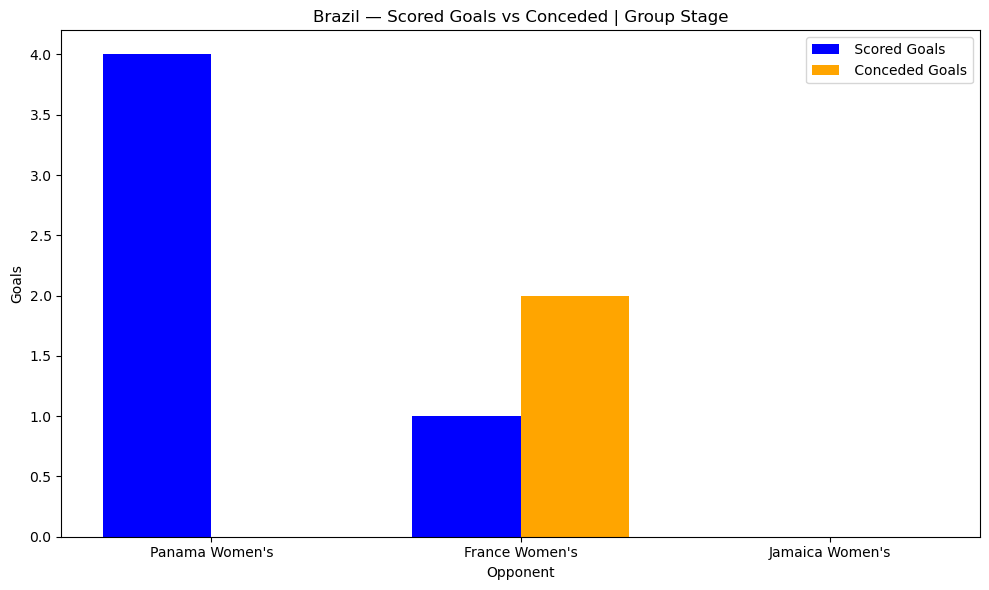

In [125]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Brazil Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Brazil — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

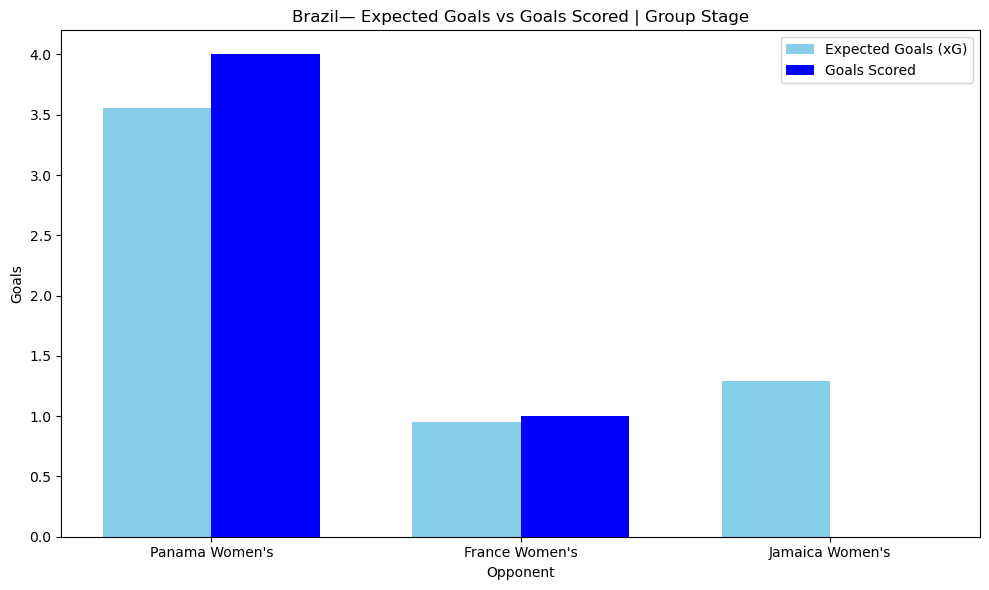

In [149]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Brazil Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Brazil— Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Brazil lost to France after scoring only one goal, tied with Jamaica, and beat Panama, scoring four goals.

# Analysis BRA-PAN

In [129]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Brazil": [
        match.loc[
            match["team"] == "Brazil Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Panama": [
        match.loc[
            match["team"] == "Panama Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Brazil", "Panama"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Brazil", "Panama"]
].round(1)


# Display table

comparison

,Metric,Brazil,Panama
0,Goals,4.0,0.0
1,xG,3.6,0.2
2,Goals Minus xG,0.4,-0.2
3,Shots,33.0,6.0
4,Shots on Target,10.0,2.0
5,Saves,2.0,8.0
6,Possession %,73.6,26.4
7,Pass Accuracy %,84.0,58.6
8,Progressive Passes,154.0,65.0
9,Progressive Carries,24.0,6.0


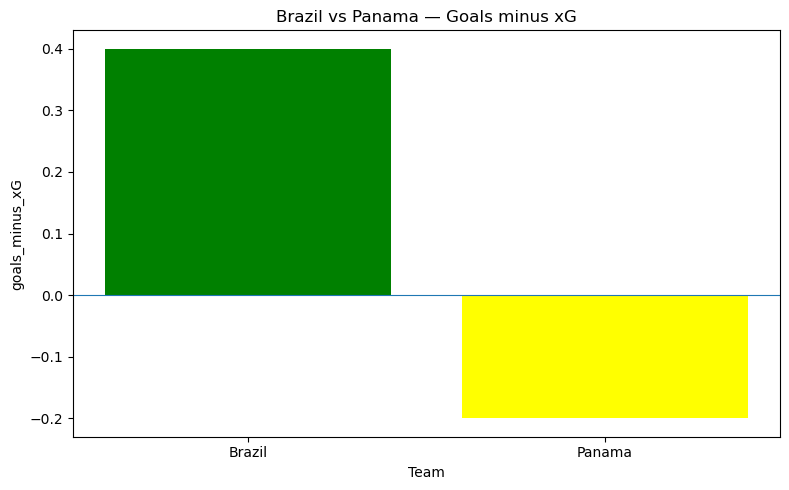

In [131]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    )
].copy()


teams = ["Brazil", "Panama"]

goals_minus_xG = [
    match.loc[match["team"] == "Brazil Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Panama Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["green", "yellow"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Brazil vs Panama — Goals minus xG")

plt.tight_layout()
plt.show()

Brazil exceeded its xG by scoring 4 goals, while Panama, having failed to score any, fell short of expectations

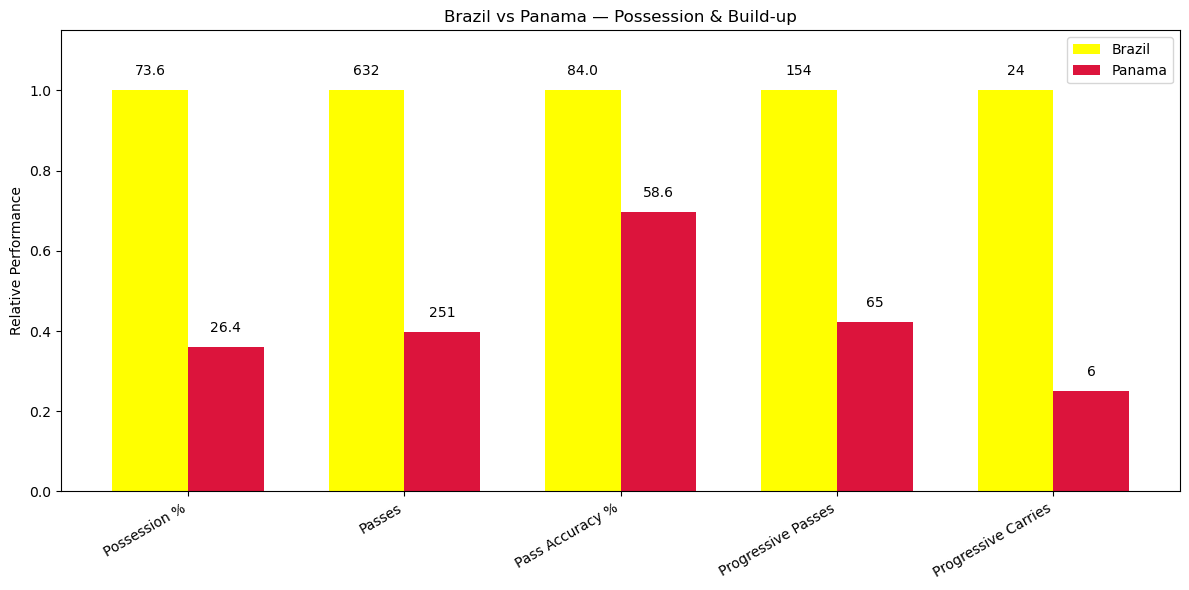

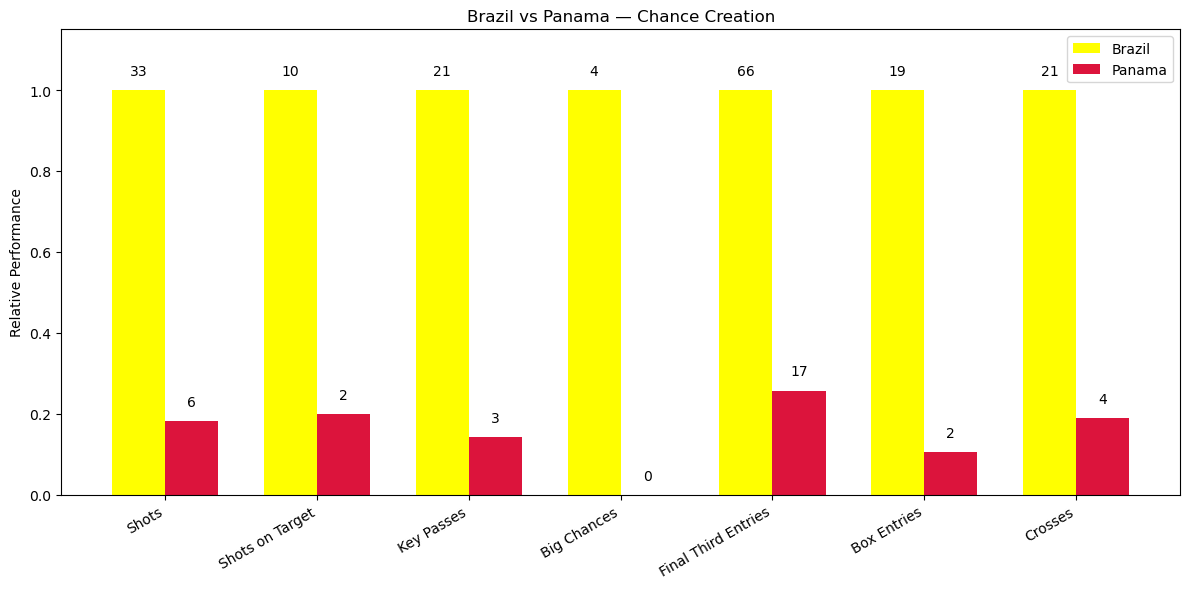

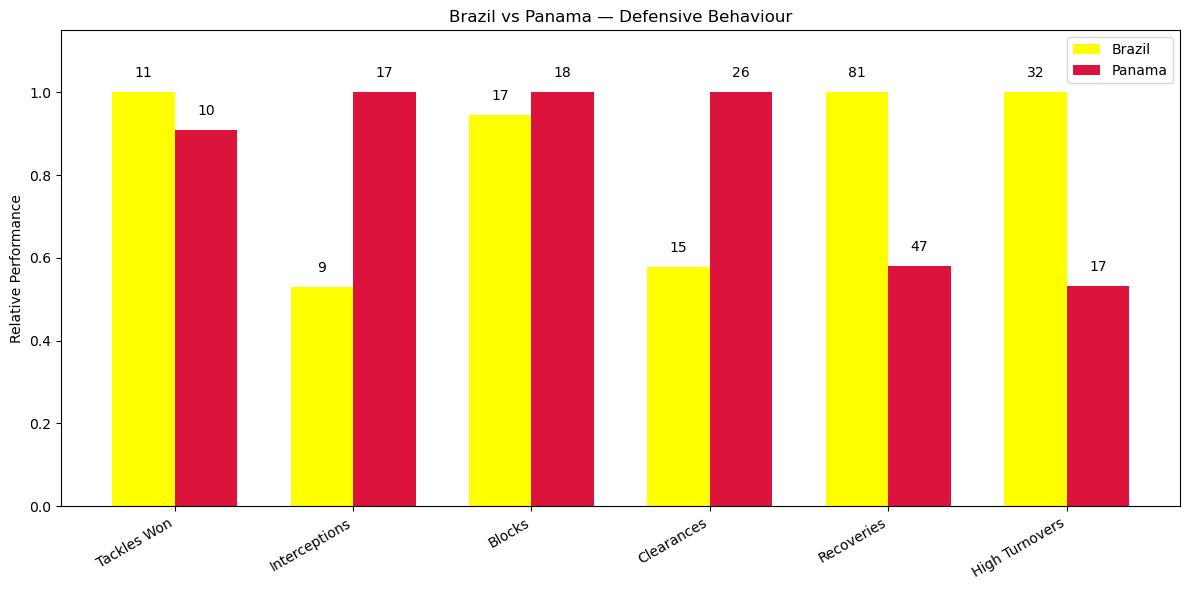

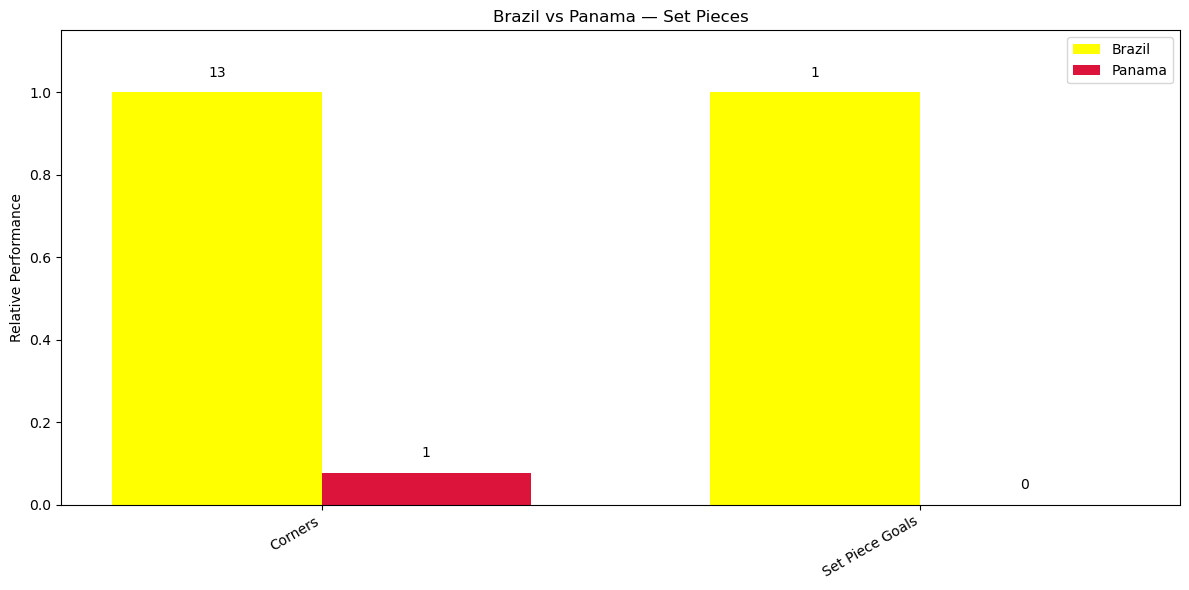

In [134]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Brazil Women's") &
        (womens_world_cup_stats["opponent"] == "Panama Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Panama Women's") &
        (womens_world_cup_stats["opponent"] == "Brazil Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Brazil": "Brazil Women's",
    "Panama": "Panama Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    br_values = np.array([
        match.loc[
            match["team"] == team_names["Brazil"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    pan_values = np.array([
        match.loc[
            match["team"] == team_names["Panama"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(br_values, pan_values)

    # Normalize
    br_normalized = np.divide(
        br_values,
        max_values,
        out=np.zeros_like(br_values),
        where=max_values != 0
    )

    pan_normalized = np.divide(
        pan_values,
        max_values,
        out=np.zeros_like(pan_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_br = plt.bar(
        x - width / 2,
        br_normalized,
        width,
        label="Brazil",
        color="yellow"
    )

    bars_pan = plt.bar(
        x + width / 2,
        pan_normalized,
        width,
        label="Panama",
        color="crimson"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_br, br_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_pan, pan_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Brazil vs Panama — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of BRA-PAN

Brazil dominated the game against Panama. <br> 
In the possession and attack statistics, the yellow team posted significantly higher numbers than its opponent. <br> 
It is worth noticing that much of the game took place in Panama’s half. <br>
The high defensive numbers were a result of Brazil’s offensive play.

# Analysis Panama's Group Stage games

In [140]:
team = "Panama Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
28,3893801,Brazil Women's,Panama Women's,Group
29,3893801,Panama Women's,Brazil Women's,Group
58,3893816,Jamaica Women's,Panama Women's,Group
59,3893816,Panama Women's,Jamaica Women's,Group
84,3893829,France Women's,Panama Women's,Group
85,3893829,Panama Women's,France Women's,Group


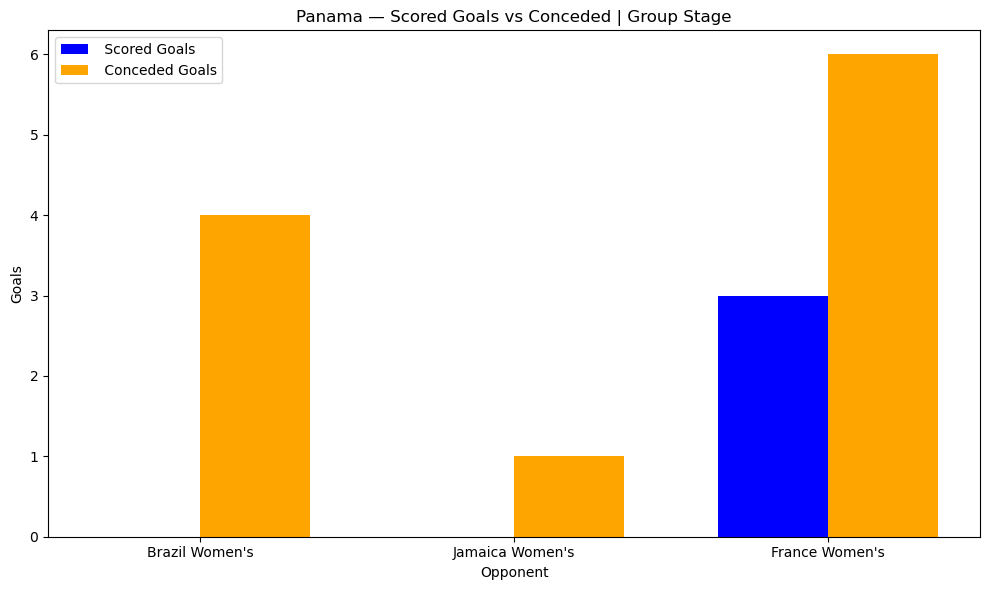

In [142]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Panama Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Panama — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Panama lost their three games in the group stage. The only team that they scored was France, by one goal.

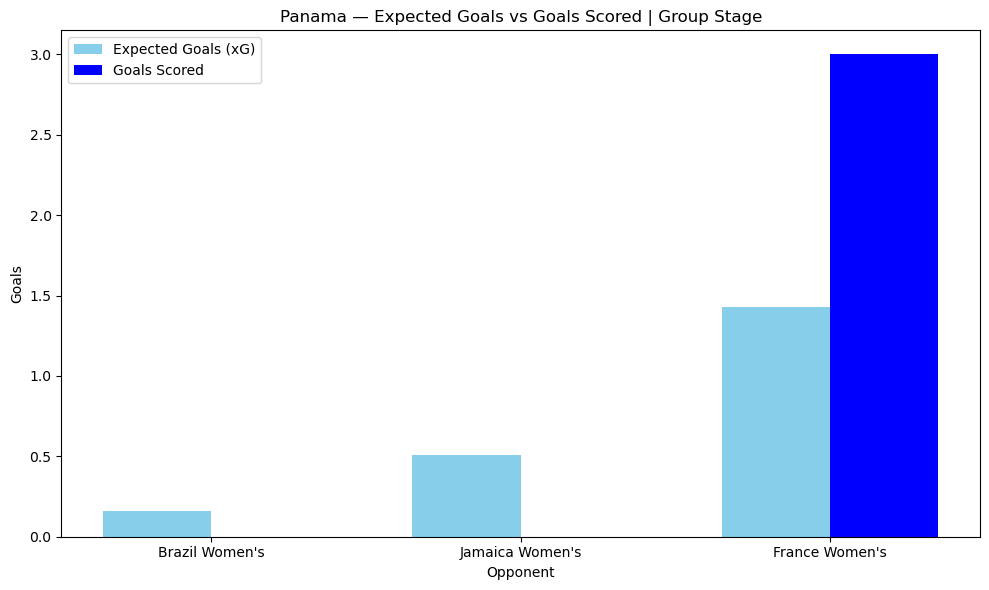

In [145]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Panama Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Panama — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Panama underperformed in both of Brazil and Jamaica by not scorring once. However, to the leader of the group they stood out in terms of xG.

# Final conclusion Group F

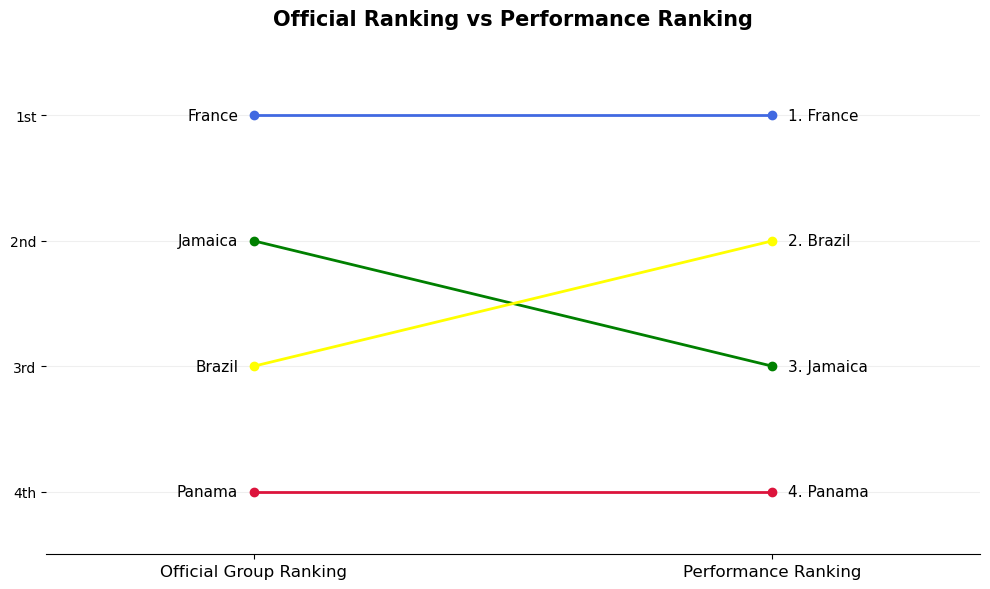

In [153]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["France", "Jamaica", "Brazil", "Panama"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 3, 2, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "France": "royalblue",
    "Jamaica": "green",
    "Brazil": "yellow",
    "Panama": "crimson"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

I kept the same rankings as the competition’s official standings, but I’d like to highlight the following teams:
- Brazil, for its offensive productivity and overall performance in every game.
- Jamaica, for its consistent performance across all three games.
- France, which—based on an analysis of the statistics—needed to substantially improve its finishing.
- Panama maintained its performance given the teams it faced.